#### Objective:
Create a simple linear regression model from a single features to predict CO2 emissions of unobserved cars based on this feature.

In [62]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [3]:
# load the data
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
# display some sample records
df.sample(10)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
278,2014,CHRYSLER,200 CONVERTIBLE FFV,COMPACT,3.6,6,A6,E,17.0,11.2,14.4,20,230
84,2014,BMW,328i xDRIVE GRAN TURISMO,FULL-SIZE,2.0,4,A8,Z,10.6,7.2,9.1,31,209
357,2014,FORD,ESCAPE,SUV - SMALL,2.0,4,AS6,X,10.9,8.0,9.6,29,221
790,2014,MINI,COOPER ROADSTER,TWO-SEATER,1.6,4,A6,Z,8.7,6.6,7.8,36,179
275,2014,CHRYSLER,200 CONVERTIBLE,COMPACT,2.4,4,A4,X,11.7,8.2,10.1,28,232
183,2014,CADILLAC,SRX,SUV - STANDARD,3.6,6,AS6,X,14.3,9.8,12.3,23,283
717,2014,MAZDA,MAZDA6 (i-ELOOP),MID-SIZE,2.5,4,AS6,X,8.4,5.9,7.3,39,168
445,2014,GMC,SAVANA 1500 PASSENGER AWD,VAN - PASSENGER,5.3,8,A4,X,18.3,14.2,16.5,17,380
154,2014,BUICK,VERANO,COMPACT,2.0,4,M6,Z,11.6,7.5,9.8,29,225
682,2014,LINCOLN,MKX AWD,SUV - SMALL,3.7,6,AS6,X,13.7,10.4,12.2,23,281


In [4]:
# statistical summary
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


#### Observations:


*   Model year has 0 standard deviation which implies this may not be useful for prediction
*   75% of the cars have combined fuel consumption (31.0 MPG) that falls within a range of up to almost three time that of the most efficient car (11.0 MPG)



In [8]:
# check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [9]:
# select features and y variable
df_subset = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
df_subset.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


array([[<Axes: title={'center': 'ENGINESIZE'}>,
        <Axes: title={'center': 'CYLINDERS'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_COMB'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

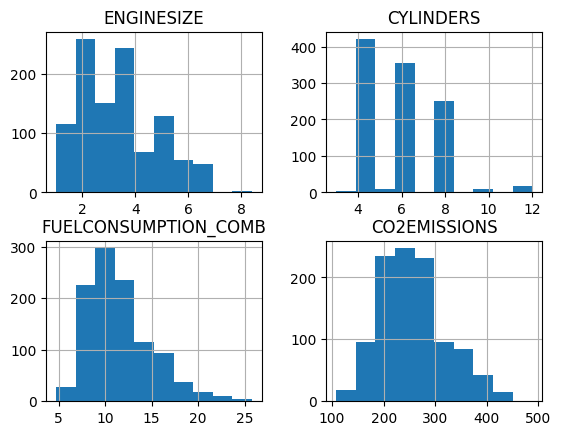

In [10]:
# histogram
df_subset.hist()

#### Observations


*   FUELCONSUMPTIOB_COMB and CO2EMISSIONS have very similar histograms.
*   Most engines have 4, 6 and 8 cylinders.
*   Most cars have engine size between 2 and 4 litres.





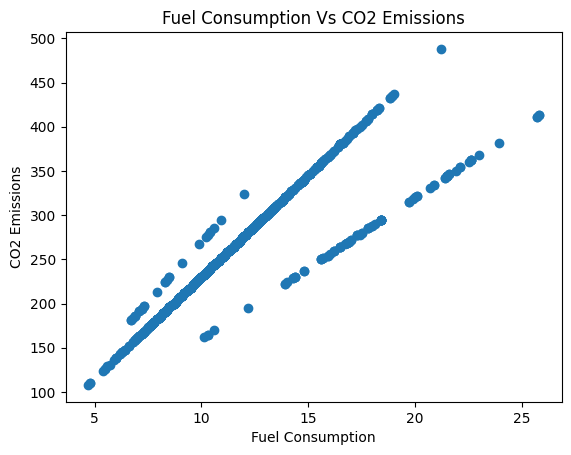

In [14]:
# scatter plot
plt.scatter(df['FUELCONSUMPTION_COMB'], df['CO2EMISSIONS'])
plt.xlabel("Fuel Consumption")
plt.ylabel("CO2 Emissions")
plt.title("Fuel Consumption Vs CO2 Emissions")
plt.show()

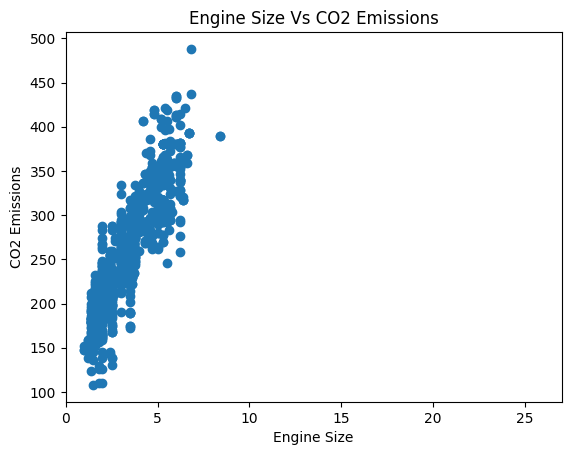

In [15]:
# scatter plot
plt.scatter(df['ENGINESIZE'], df['CO2EMISSIONS'])
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Engine Size Vs CO2 Emissions")

# set xlim to compare with above plot
plt.xlim(0, 27)
plt.show()

In [55]:
# extract input feature and labels
X = df_subset[['FUELCONSUMPTION_COMB']].to_numpy()
y = df_subset[['CO2EMISSIONS']].to_numpy()
print("X values\n", X)
print("y values\n", y)

X values
 [[ 8.5]
 [ 9.6]
 [ 5.9]
 ...
 [11.8]
 [11.3]
 [12.8]]
y values
 [[196]
 [221]
 [136]
 ...
 [271]
 [260]
 [294]]


In [56]:
# create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print("X train: ", X_train.shape)
print("X test: ", X_test.shape)
print("y train: ", y_train.shape)
print("y test: ", y_test.shape)

print(type(X_train))

X train:  (746, 1)
X test:  (321, 1)
y train:  (746, 1)
y test:  (321, 1)
<class 'numpy.ndarray'>


In [57]:
# build the linear regression model
model = LinearRegression()

# train the model
# reshape my be needed since X_train is a 1D array and sklearn model expect 2D arrays (num_observations, num_features)
# infer the number of observations using -1
model.fit(X_train.reshape(-1, 1), y_train)

# print the regression parameters
print("Intercept: ", model.intercept_)
print("Coefficient: ", model.coef_[0])

Intercept:  [69.20775487]
Coefficient:  [16.15630616]


Text(0, 0.5, 'CO2 Emissions')

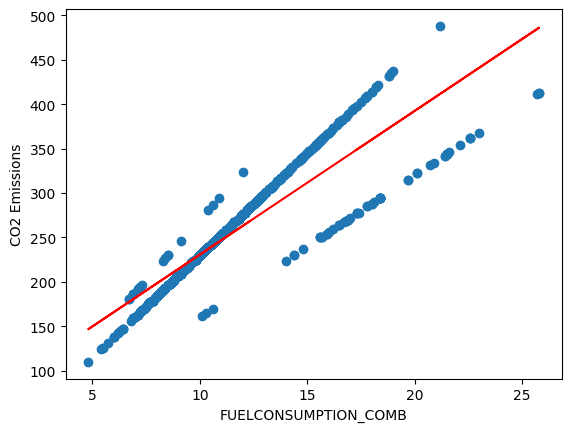

In [58]:
# visualize model output (regression line goodness-of-fit) with training data
plt.scatter(X_train, y_train)
#plt the regression line y = mx+c
plt.plot(X_train, model.coef_[0]*X_train + model.intercept_, 'r')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2 Emissions")

In [59]:
# predict the values
y_predict = model.predict(X_test.reshape(-1, 1))
# y_predict is numpy ndarray
print((y_predict[:10]))

[[282.47099613]
 [224.30829397]
 [276.00847366]
 [224.30829397]
 [214.61451027]
 [242.08023074]
 [330.93991459]
 [287.31788797]
 [287.31788797]
 [335.78680644]]


In [63]:
# evaluate the model
print("R2 Score: ", r2_score(y_test, y_predict))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_predict))
print("Mean Squared Error: ", mean_squared_error(y_test, y_predict))
print("Root Mean Squared Error: ", root_mean_squared_error(y_test, y_predict))

R2 Score:  0.8000872270086814
Mean Absolute Error:  20.762901664763724
Mean Squared Error:  806.347573270993
Root Mean Squared Error:  28.396259846518397
